# Домашняя работа №1: Метод K-ближайших соседей (KNN)

**Цель:**  
1. Освоить работу алгоритма KNN для задач многоклассовой классификации и регрессии.  
2. Научиться рассчитывать и интерпретировать метрики качества.  


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_iris, load_wine, load_diabetes
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier, KNeighborsRegressor
from sklearn.metrics import (
    accuracy_score, confusion_matrix, classification_report,
    mean_absolute_error, mean_squared_error, r2_score
)


## Задача 1. KNN для многоклассовой классификации

1 (1 балл). Выберите набор данных из датасетов sklean с несколькими классами (например, `Iris` или `Wine` – оба датасета импортированы в предыдущей ячейке).  
2 (1 балл). Разделите данные на обучающую и тестовую выборки.    
3 (1 балл). Обучите модель `KNeighborsClassifier`.  
4 (1 балл). Постройте confusion_matrix.

5 (1 балл). Посчитайте метрики оценки качества для задач классификации: accuracy, precision, recall, f1-score и сделайте выводы о качестве модели.  

Судя по наличию импорта StandardScaler применяем масштабирование фичей(хоть это и не указано в задании) - важность признаков будет одинакой.

In [7]:
#удобно
from sklearn.pipeline import Pipeline

In [14]:
from sklearn.metrics import precision_score, recall_score, f1_score

In [15]:
# Сюда нужно написать код решения задания
ds = load_iris()
X = ds.data
y = ds.target
class_names = ds.target_names

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

knn_pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("knn", KNeighborsClassifier(n_neighbors=5))
])

knn_pipe.fit(X_train, y_train)

y_pred = knn_pipe.predict(X_test)

cm = confusion_matrix(y_test, y_pred)
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:\n", cm)
print("\n")

print("Метрики:")
acc = accuracy_score(y_test, y_pred)
print(f"Accuracy: {acc:.4f}\n")

print(classification_report(y_test, y_pred, target_names=class_names, digits=4))

Confusion Matrix:
 [[10  0  0]
 [ 0 10  0]
 [ 0  2  8]]


Метрики:
Accuracy: 0.9333

              precision    recall  f1-score   support

      setosa     1.0000    1.0000    1.0000        10
  versicolor     0.8333    1.0000    0.9091        10
   virginica     1.0000    0.8000    0.8889        10

    accuracy                         0.9333        30
   macro avg     0.9444    0.9333    0.9327        30
weighted avg     0.9444    0.9333    0.9327        30



Наглядная визуализация Confusion Matrix

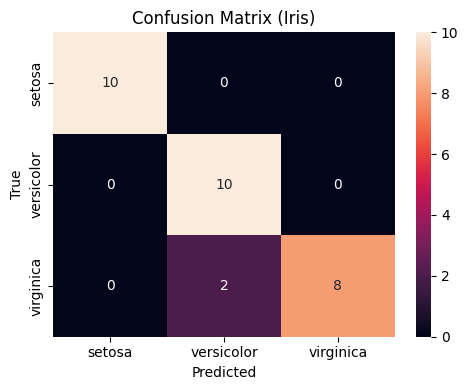

In [16]:
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt="d",
            xticklabels=class_names,
            yticklabels=class_names)
plt.title(f"Confusion Matrix (Iris)")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.tight_layout()
plt.show()

Выводы:

Общая точность (accuracy) = 0.933 - хороший результат.

Класс Setosa: precision = 1.00, recall = 1.00, то есть класс отделён идеально.

Класс Versicolor: precision = 0.833, recall = 1.00, то есть все истинные versicolor найдены, но есть ложные срабатывания(часть virginica принята за versicolor)

Virginica: precision = 1.00, recall = 0.80, то есть ошибок пропуска 2 шт.



## Задача 2. KNN для регрессии

1 (1 балл). Выберите набор данных из датасетов sklearn (например, `load_diabetes` – он импортирован в ячейке с импортами).  
2 (1 балл). Разделите данные на обучающую и тестовую выборки.  
3 (1 балл). Обучите модель `KNeighborsRegressor`.  
4 (1 балл). Посчитайте метрики оценки качества для задач регрессии: `MAE`, `RMSE` и `R²`, сделайте выводы о качестве модели.  
5 (1 балл). Визуализируйте реальные и предсказанные значения на графике.  

Метрики:
MAE : 42.778
RMSE: 55.204
R²  : 0.425


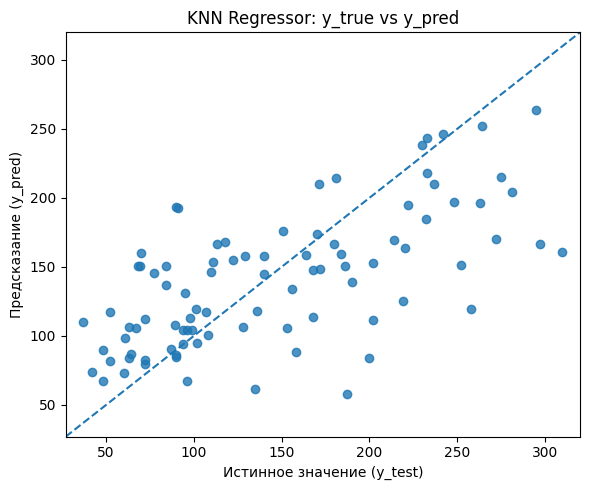

In [18]:
# Сюда нужно написать код решения задачи
ds = load_diabetes()
X, y = ds.data, ds.target

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model = Pipeline([
    ("scaler", StandardScaler()),
    ("knn", KNeighborsRegressor(n_neighbors=5))
])

model.fit(X_train, y_train)


y_pred = model.predict(X_test)

mae  = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2   = r2_score(y_test, y_pred)

print("Метрики:")
print(f"MAE : {mae:.3f}")
print(f"RMSE: {rmse:.3f}")
print(f"R²  : {r2:.3f}")

plt.figure(figsize=(6,5))
plt.scatter(y_test, y_pred, alpha=0.8)
lims = [min(y_test.min(), y_pred.min())-10, max(y_test.max(), y_pred.max())+10]
plt.plot(lims, lims, linestyle="--")
plt.xlim(lims); plt.ylim(lims)
plt.xlabel("Истинное значение (y_test)")
plt.ylabel("Предсказание (y_pred)")
plt.title("KNN Regressor: y_true vs y_pred")
plt.tight_layout()
plt.show()

Выводы:

$R^2$ = 0.425 — модель объясняет 42% дисперсии цели, то есть качество среднее, хоть и лучше константного предсказания.

MAE = 42.8, RMSE = 55.2. Ошибка в среднем десятки единиц(MAE). RMSE > MAE, значит, есть более крупные выбросы.

По графику точки заметно рассеиваются вокруг диагонали: видно регрессию к среднему.

## Задача 3. Анализ влияния числа соседей

1 (1 балл). Изучите, как Accuracy (для классификации) или R² (для регрессии) зависит от k.  
2 (1 балл). Постройте график зависимости выбранной метрики от числа соседей.  
3 (1 балл). Сделайте вывод, как выбор k влияет на качество модели.


Лучший k по тесту: 1  |  Accuracy = 0.9667


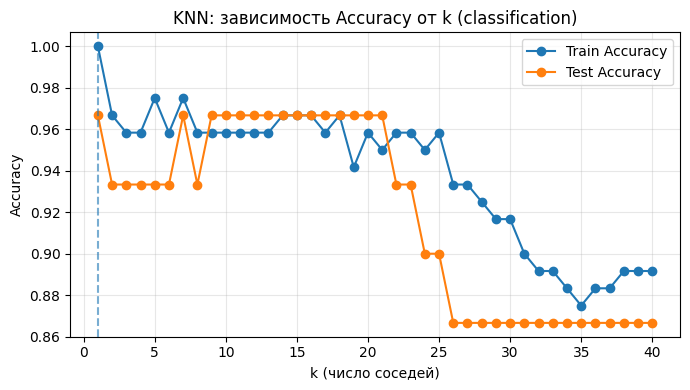

In [19]:
# Сюда нужно написать код решения задачи
ds = load_iris()
X, y = ds.data, ds.target
metric_name = "Accuracy"
Model = KNeighborsClassifier
scorer = accuracy_score

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

ks = range(1, 41)
train_scores, test_scores = [], []

for k in ks:
    pipe = Pipeline([
        ("scaler", StandardScaler()),
        ("knn", Model(n_neighbors=k))
    ])
    pipe.fit(X_train, y_train)

    y_tr = pipe.predict(X_train)
    y_te = pipe.predict(X_test)

    train_scores.append(scorer(y_train, y_tr))
    test_scores.append(scorer(y_test,  y_te))

best_idx = int(np.argmax(test_scores))
best_k = list(ks)[best_idx]
best_score = test_scores[best_idx]

print(f"Лучший k по тесту: {best_k}  |  {metric_name} = {best_score:.4f}")

plt.figure(figsize=(7,4))
plt.plot(ks, train_scores, marker="o", label=f"Train {metric_name}")
plt.plot(ks, test_scores,  marker="o", label=f"Test {metric_name}")
plt.axvline(best_k, ls="--", alpha=0.6)
plt.xlabel("k (число соседей)")
plt.ylabel(metric_name)
plt.title(f"KNN: зависимость {metric_name} от k (classification)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

Малые k (1–3): высокая точность на тренировочной выборке (k=1 даёт около 1.0) и чуть ниже на тесте - модель склонна к переобучению и высокой вариативности (зависит от шума/выбросов): окрестность очень узкая, решение цепляется за единичные точки. Любая шумная/ошибочно размеченная точка меняет ответ. Граница классов получается рваной и сложной - вариативность высокая.

Средние k (7–20): самый стабильный диапазон. test accuracy = 0.96–0.97 при умеренном снижении train. Это оптимум по балансу смещения/разброса.

Большие k (>25): и train, и test падают (test = 0.86–0.90) — сильное сглаживание, недообучение. Берём широкую окрестность, значит, голосуют многие, в том числе точки другого класса/далёкие по смыслу. Граница становится слишком сглаженной, размывает локальные структуры и меньшинственные кластеры, таким образом смещение растёт, модель недообучается.


Лучший k по тесту: 6  |  R^2 = 0.4543


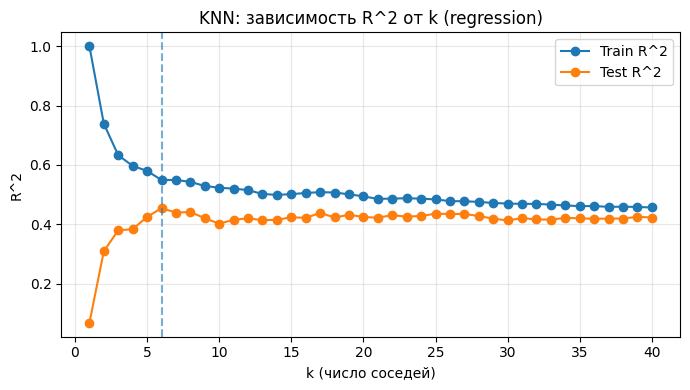

In [22]:
ds = load_diabetes()
X, y = ds.data, ds.target
metric_name = "R^2"
Model = KNeighborsRegressor
scorer = r2_score

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

ks = range(1, 41)
train_scores, test_scores = [], []

for k in ks:
    pipe = Pipeline([
        ("scaler", StandardScaler()),
        ("knn", Model(n_neighbors=k))
    ])
    pipe.fit(X_train, y_train)

    y_tr = pipe.predict(X_train)
    y_te = pipe.predict(X_test)

    train_scores.append(scorer(y_train, y_tr))
    test_scores.append(scorer(y_test,  y_te))

best_idx = int(np.argmax(test_scores))
best_k = list(ks)[best_idx]
best_score = test_scores[best_idx]

print(f"Лучший k по тесту: {best_k}  |  {metric_name} = {best_score:.4f}")

plt.figure(figsize=(7,4))
plt.plot(ks, train_scores, marker="o", label=f"Train {metric_name}")
plt.plot(ks, test_scores,  marker="o", label=f"Test {metric_name}")
plt.axvline(best_k, ls="--", alpha=0.6)
plt.xlabel("k (число соседей)")
plt.ylabel(metric_name)
plt.title(f"KNN: зависимость {metric_name} от k (regression)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

Малые k (1–2): train $R^2$ = 1.0, test $R^2$ низкий. Модель помнит соседей, сильно переобучается.

Средние k (5–8): достигается максимум тестового качества — это оптимальный баланс смещения/разброса.

Большие k (10–15): и train, и test $R^2$ постепенно снижаются и выходят на плато(0.42) - сильное сглаживание, недообучение.